# Description

This notebook demonstrate how to download MachineLearningCSV from the CICIDS2017 dataset.

*Author*: **Mahendra Data** mahendra.data@dbms.cs.kumamoto-u.ac.jp

License: **BSD 3 clause**

# Mounting Google Drive

We will save the downloaded dataset to Google Drive.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Downloading the dataset

The description of CICIDS2017 dataset is accessible at https://www.unb.ca/cic/datasets/ids-2017.html

There are three versions available:

1. Raw network captured data (PCAPs),
2. Generated Labelled Flows, and
3. Machine Learning CSV.

In this notebook, we will download the `MachineLearningCSV.zip` version of this dataset.

When downloading this dataset, we rename the `MachineLearningCSV.zip` file to `MachineLearningCVE.zip` because in the `MachineLearningCSV.md5` the target filename is `MachineLearningCVE.zip`.

In [2]:
!wget -nc -O MachineLearningCVE.zip http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.zip

--2026-05-08 10:53:06--  http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.zip
Connecting to 205.174.165.80:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cicresearch.ca/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.zip [following]
--2026-05-08 10:53:06--  https://cicresearch.ca/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.zip
Resolving cicresearch.ca (cicresearch.ca)... 205.174.165.80
Connecting to cicresearch.ca (cicresearch.ca)|205.174.165.80|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.unb.ca/cic/datasets/index.html [following]
--2026-05-08 10:53:07--  https://www.unb.ca/cic/datasets/index.html
Resolving www.unb.ca (www.unb.ca)... 131.202.255.201
Connecting to www.unb.ca (www.unb.ca)|131.202.255.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 108871 (106K) [text/html]
Saving to: ‘MachineLearningCVE.zip’

MachineLearningCVE. 

# Integrity check

Download `MachineLearningCSV.md5` file to check the integrity of the downloaded file.

In [3]:
!wget -nc http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.md5

--2026-05-08 10:53:18--  http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.md5
Connecting to 205.174.165.80:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cicresearch.ca/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.md5 [following]
--2026-05-08 10:53:19--  https://cicresearch.ca/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.md5
Resolving cicresearch.ca (cicresearch.ca)... 205.174.165.80
Connecting to cicresearch.ca (cicresearch.ca)|205.174.165.80|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.unb.ca/cic/datasets/index.html [following]
--2026-05-08 10:53:20--  https://www.unb.ca/cic/datasets/index.html
Resolving www.unb.ca (www.unb.ca)... 131.202.255.201
Connecting to www.unb.ca (www.unb.ca)|131.202.255.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 108871 (106K) [text/html]
Saving to: ‘MachineLearningCSV.md5’

MachineLearningCSV. 

Checking the file integrity.

In [4]:
!md5sum -c MachineLearningCSV.md5

md5sum: MachineLearningCSV.md5: no properly formatted MD5 checksum lines found


If the downloaded dataset is correct, then the output should be like this

`MachineLearningCVE.zip: OK`

# Saving the dataset

Save the zip and extracted files to Google Drive.

In [5]:
!mkdir -p "/content/drive/My Drive/CICIDS2017/"

!cp MachineLearningCVE.zip "/content/drive/My Drive/CICIDS2017/"

In [6]:
!unzip "/content/drive/My Drive/CICIDS2017/MachineLearningCVE.zip" -d "/content/drive/My Drive/CICIDS2017/Extraction/"

Archive:  /content/drive/My Drive/CICIDS2017/MachineLearningCVE.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/drive/My Drive/CICIDS2017/MachineLearningCVE.zip or
        /content/drive/My Drive/CICIDS2017/MachineLearningCVE.zip.zip, and cannot find /content/drive/My Drive/CICIDS2017/MachineLearningCVE.zip.ZIP, period.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd

chemin_fichier = '/content/drive/MyDrive/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'

print("⏳ Chargement des données en cours...")
df = pd.read_csv(chemin_fichier)
print("✅ Données chargées avec succès !\n")

print("📊 TAILLE DU DATASET :")
print(f"Nombre de lignes (connexion réseau) : {df.shape[0]}")
print(f"Nombre de colonnes (caractéristiques) : {df.shape[1]}\n")

print("🎯 DISTRIBUTION DES CLASSES (Trafic normal vs Attaques) :")
print(df[' Label'].value_counts())

⏳ Chargement des données en cours...
✅ Données chargées avec succès !

📊 TAILLE DU DATASET :
Nombre de lignes (connexion réseau) : 286467
Nombre de colonnes (caractéristiques) : 79

🎯 DISTRIBUTION DES CLASSES (Trafic normal vs Attaques) :
 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


In [14]:
import pandas as pd
import numpy as np

# 1. Nettoyer les espaces invisibles dans les noms des colonnes
print("DÉBUT DU NETTOYAGE DES DONNÉES...")
df.columns = df.columns.str.strip()

# 2. Compter les valeurs manquantes (NaN)
valeurs_manquantes = df.isnull().sum()
print(f"Total des valeurs vides (NaN) trouvées : {valeurs_manquantes.sum()}")

# 3. Compter les valeurs infinies (très commun dans les calculs de réseau)
valeurs_infinies = df.replace([np.inf, -np.inf], np.nan).isnull().sum().sum() - valeurs_manquantes
print(f"Total des valeurs infinies trouvées : {valeurs_infinies}")

# 4. Vérifier les lignes en double
doublons = df.duplicated().sum()
print(f"👯 Nombre de lignes parfaitement identiques (doublons) : {doublons}")


DÉBUT DU NETTOYAGE DES DONNÉES...
Total des valeurs vides (NaN) trouvées : 15
Total des valeurs infinies trouvées : Destination Port               742
Flow Duration                  742
Total Fwd Packets              742
Total Backward Packets         742
Total Length of Fwd Packets    742
                              ... 
Idle Mean                      742
Idle Std                       742
Idle Max                       742
Idle Min                       742
Label                          742
Length: 79, dtype: int64
👯 Nombre de lignes parfaitement identiques (doublons) : 72353


In [15]:
import pandas as pd

print(" DÉMARRAGE DU NETTOYAGE...")

# 1. On transforme les infinis en "NaN" (vide) pour pouvoir tout traiter d'un coup
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. On supprime toutes les lignes qui contiennent un vide (NaN)
df.dropna(inplace=True)

# 3. On supprime toutes les lignes en double
df.drop_duplicates(inplace=True)

print(" Nettoyage terminé !")
print(f" Nouvelle Taile du Dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

 DÉMARRAGE DU NETTOYAGE...
 Nettoyage terminé !
 Nouvelle Taile du Dataset : 213777 lignes et 79 colonnes.


In [17]:
from sklearn.preprocessing import LabelEncoder

print(" DÉBUT DE L'ENCODAGE...")

# 1. On initialise notre "traducteur"
encoder = LabelEncoder()

# 2. On traduit la colonne 'Label' en chiffres et on remplace l'ancienne
df['Label'] = encoder.fit_transform(df['Label'])

# 3. On crée un petit dictionnaire pour se souvenir de qui est 0 et qui est 1
correspondance = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print(" Encodage terminé !")
print("\nVoici le dictionnaire de traduction que l'IA va utiliser :")
for nom, chiffre in correspondance.items():
    print(f" - {nom} est devenu le chiffre : {chiffre}")

# 4. On vérifie rapidement les données
print("\nAperçu de la colonne Label maintenant (que des chiffres) :")
print(df['Label'].value_counts())

 DÉBUT DE L'ENCODAGE...
 Encodage terminé !

Voici le dictionnaire de traduction que l'IA va utiliser :
 - BENIGN est devenu le chiffre : 0
 - PortScan est devenu le chiffre : 1

Aperçu de la colonne Label maintenant (que des chiffres) :
Label
0    123083
1     90694
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(" SÉPARATION ET NORMALISATION DES DONNÉES...")

# 1. Séparer les "Indices" (X) de la "Réponse" (y)
X = df.drop('Label', axis=1) # X contient tout SAUF le Label
y = df['Label']              # y contient UNIQUEMENT le Label

# 2. Découpage Entraînement (80%) / Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
print(f"Découpage terminé : {X_train.shape[0]} lignes pour l'entraînement et {X_test.shape[0]} pour le test.")

# 3. Normalisation
scaler = StandardScaler()

# On "calcule" la mise à l'échelle sur l'entraînement et on l'applique
X_train = scaler.fit_transform(X_train)

# On applique la MÊME échelle sur les données de test
X_test = scaler.transform(X_test)

print("Normalisation Terminée !")

 SÉPARATION ET NORMALISATION DES DONNÉES...
Découpage terminé : 171021 lignes pour l'entraînement et 42756 pour le test.
Normalisation Terminée !


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

print("INITIALISATION (Random Forest)...")
# 1. On crée le modèle
modele_rf= RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print(" Entraînement en cours... ")
debut = time.time()

# 2. L'IA s'entraîne avec le corrigé (X_train et y_train)
modele_rf.fit(X_train, y_train)
fin = time.time()

print(f" Entraînement terminé en {round(fin - debut, 2)} secondes !")

# 3. L'IA passe le test final sur les données cachées (X_test)
predictions = modele_rf.predict(X_test)

precision = accuracy_score(y_test, predictions)
print(f" Précision sur de nouvelles données : {round(precision * 100, 2)} %")

INITIALISATION (Random Forest)...
 Entraînement en cours... 
 Entraînement terminé en 42.41 secondes !
 Précision sur de nouvelles données : 100.0 %


ANALYSE DÉTAILLÉE DES PERFORMANCES...

 Rapport de classification :
              precision    recall  f1-score   support

  BENIGN (0)       1.00      1.00      1.00     24555
PortScan (1)       1.00      1.00      1.00     18201

    accuracy                           1.00     42756
   macro avg       1.00      1.00      1.00     42756
weighted avg       1.00      1.00      1.00     42756



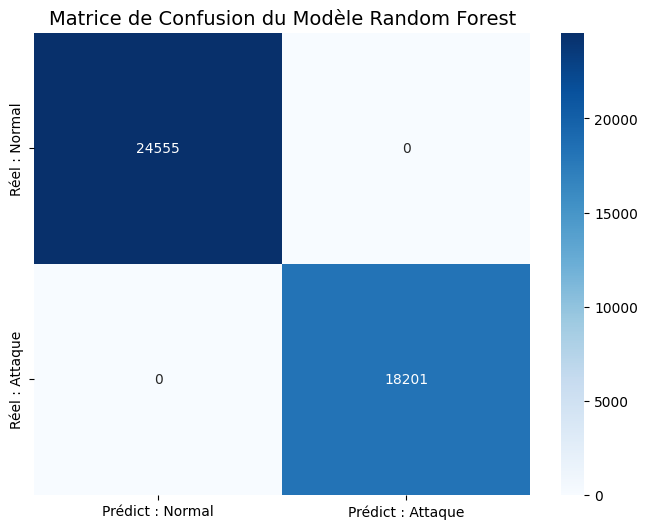

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("ANALYSE DÉTAILLÉE DES PERFORMANCES...")

# 1. Le rapport de classification détaillé
print("\n Rapport de classification :")
print(classification_report(y_test, predictions, target_names=['BENIGN (0)', 'PortScan (1)']))

# 2. Création de la Matrice de Confusion graphique
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prédict : Normal', 'Prédict : Attaque'], yticklabels=['Réel : Normal', 'Réel : Attaque'])
plt.title('Matrice de Confusion du Modèle Random Forest', fontsize=14 )
plt.show()

 INITIALISATION DE L'IA (SVM Linéaire)...
 Entraînement en cours... (Le SVM cherche la ligne de séparation parfaite)
 Entraînement terminé en 154.57 secondes !
 Précision du SVM sur de nouvelles données : 99.89 %



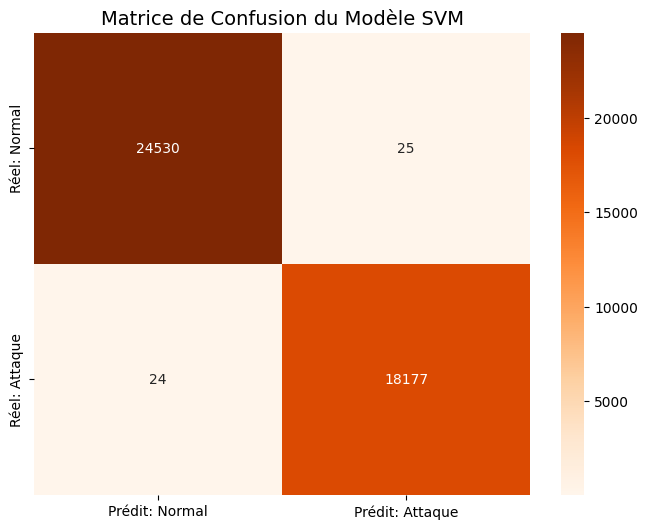

In [23]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time
import seaborn as sns
import matplotlib.pyplot as plt

print(" INITIALISATION DE L'IA (SVM Linéaire)...")

# 1. On crée le modèle SVM
# dual=False est recommandé quand on a plus de lignes que de colonnes
modele_svm = LinearSVC(random_state=42, dual=False, max_iter=1000)

print(" Entraînement en cours... (Le SVM cherche la ligne de séparation parfaite)")
debut = time.time()

# 2. L'IA s'entraîne avec les données NORMALISÉES
# (Le SVM est très sensible aux échelles, heureusement on a fait le StandardScaler juste avant !)
modele_svm.fit(X_train, y_train)

fin = time.time()
print(f" Entraînement terminé en {round(fin - debut, 2)} secondes !")

# 3. L'IA passe le test final
predictions_svm = modele_svm.predict(X_test)

# 4. On calcule sa note !
precision_svm = accuracy_score(y_test, predictions_svm)
print(f" Précision du SVM sur de nouvelles données : {round(precision_svm * 100, 2)} %\n")

# 5. Affichage de la Matrice de Confusion pour comparer avec le Random Forest
cm_svm = confusion_matrix(y_test, predictions_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prédit: Normal', 'Prédit: Attaque'],
            yticklabels=['Réel: Normal', 'Réel: Attaque'])

plt.title('Matrice de Confusion du Modèle SVM', fontsize=14)
plt.show()

Now the dataset is saved to your Google Drive at `CICIDS2017` folder.